#### Holt-Winters method

1.  Holt-Winters is an extension of Simple Exponential Smoothing.

2.  It is known as Triple Exponential Smoothing.

3.  It is a time series forecasting technique that is used when the data contains

    (a.)    trend

    (b.)    seasonality

    (c.)    levels

4.  It plays an inportant role in handling all the terns, seasonality and the levels in the data.


#### Why Holt-Winters is better than SES ?

1.  Holt-Winters is better than SES because:---

    (a.)    it can handle trend

    (b.)    it can handle seasonality


#### Application of Holt- Winters:----

1.  Suppose we are considering an airline passengers dataset that has passengers

    (a.) These passengers increase every year =============>   trend

    (b.) The number of passengers increases exponentially during holiday seasons ==========>  seasonality

So here Holt-Winters method work well.


#### Components of Holt-Winters :-------------

1.  There are three components of Holt-Winters . They are as follows :------

    (a.)    Level ============>  Current Average Value.

    (b.)    Trend ============>  Increasing or decreasing direction.

    (c.)    seasonality =======>  repeating patterns.


#### Types of Holt-Winters :----------------

1.  There are two types of Holt-Winters. They are as follows :------

    (a.)    Additive ============>  Here seasonal variation remains constant.

            Ex ======>  +10 increase every year

    (b.)    Multiplicative =========>  Here seasonal variation increases with respect to time.

            Ex ======>  10% increase every year.

#### Step 1: Import all the necessary libraries


In [380]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns


from    statsmodels.tsa.holtwinters import  ExponentialSmoothing

#### OBSERVATIONS:

1.  ExponentialSmoothing ===========> It is an important component used in Holt Winters method that handles the trend, seasonality and the levels.

#### Step 2: Load the dataset

In [381]:
#### Laod the dataset

df = pd.read_csv('AirPassengers.csv')

In [382]:
df

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


#### OBSERVATIONS:

1.  The above dataset depicts the passengers data at the starting date of every month ranging from 1949 till 1960.

#### Step 3: Perform Data Exploration

In [383]:
#### get the first five rows of the dataset

df.head()

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [384]:
#### get the last five rows of the dataset

df.tail()

,date,value
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390
143,1960-12-01,432


In [385]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 144


In [386]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (144, 2)


In [387]:
#### get the columns used in the dataset

df.columns

Index(['date', 'value'], dtype='object')

In [388]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    144 non-null    object
 1   value   144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


#### OBSERVATIONS:

1.  The Month column is object in type.

In [389]:
#### get the descriptive summary statistics about the numerical columns used in the dataset

df.describe()

,value
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [390]:
#### get the descriptive summary statistics about the categorical columns used in the dataset

df.describe(include='object')

,date
count,144
unique,144
top,1949-01-01
freq,1


#### OBSERVATIONS:

1.  The above dataset explains the descriptive statictical summary for each column used in the dataset.

#### Step 4: Perform Data Cleaning and Feature Engineering

In [391]:
#### convert the object type of date column to datetime

df['date'] =   pd.to_datetime(df['date'])

In [392]:
#### get the information about the columns used in the revised dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    144 non-null    datetime64[ns]
 1   value   144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


#### OBSERVATIONS:

1.  The onject type in the Month column has been converted to datetime.

In [393]:
#### To check for the NULL records in the dataset

df.isnull().sum()

date     0
value    0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [394]:
#### To check for the duplicate records used in the dataset

df[df.duplicated()]

,date,value


#### OBSERVATIONS:

1.  There are no duplicate records used in the dataset.

In [395]:
#### Set the Month column as an index

df.set_index('date',inplace=True)

In [396]:
df

,value
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


#### OBSERVATIONS:

1.  The month column has been set as an index in the dataframe.

In [397]:
#### Rename the column name 'value' to 'Passengers' in the dataset

df.rename(columns={'value':'Passengers'},inplace=True)

In [398]:
df

,Passengers
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


#### OBSERVATIONS:

1.  The column name 'value' has been renamed to 'Passengers' in the dataset.

#### Step 5: Plot the Original Time series data

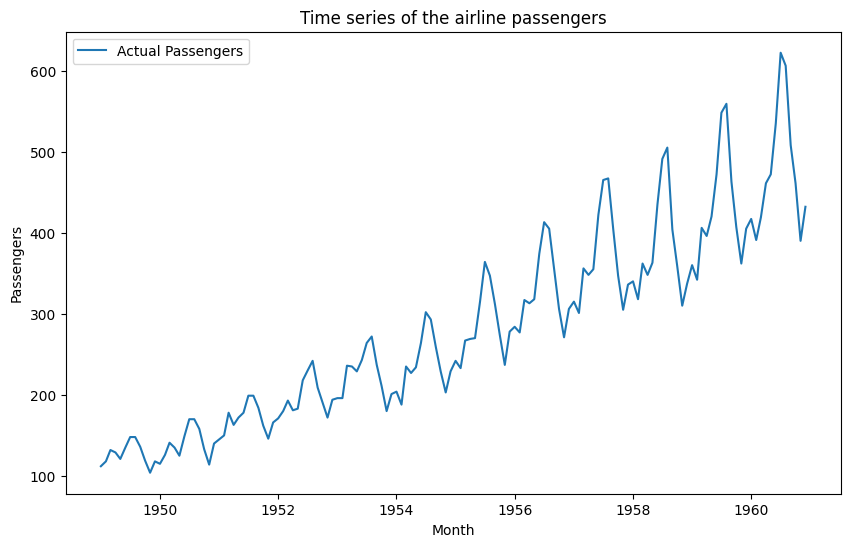

In [399]:
plt.figure(figsize=(10,6))

#### plot the original time series
plt.plot(df.index, df['Passengers'], label = 'Actual Passengers')

#### give the title of the graph
plt.title('Time series of the airline passengers')

#### give the x axis of the graph
plt.xlabel('Month')

#### give the y-axis of the graph
plt.ylabel('Passengers')

#### give the legend of the graph
plt.legend()

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The above graph represents the passengers data for the starting date of every month starting from 1944 till 1960.

2.  With the increase in years, the number of passengers also increases, so the trned also increases.

3.  As the trend continuously increases in the upward direction, so the time series is non stationary in nature.

#### Step 6: Built the Holt Winters model

In [400]:
from    statsmodels.tsa.holtwinters import  ExponentialSmoothing

#### create an object for Exponential Smoothing

model   =   ExponentialSmoothing(
    df['Passengers']                                ,
    trend               =       'add'               ,
    seasonal            =       'add'               ,
    seasonal_periods    =         12         
)

c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


#### OBSERVATIONS:

1.  The Exponential Smoothing function module is called from the statsmodels.

2.  Then the object of Exponential Smoothing is created with the following parameters :-------------

    (a.)    df['Passengers']    =============>   Dataset on which the model is trained.

    (b.)    trend = 'add'       =============>   Trend component is added. The  model will learn either upward/downward curve.

    (c.)    seasonal = 'add'    =============>   Seasonal component is added. Seasonal effect will remain constant over a period of time.

    (d.)    seasonal-periods = 12 ============>  Seasonal period is added. The season will repeat after every 12 months.

#### Step 7: Train the model

In [401]:
#### Train the Holt Winters model

model_fit = model.fit()

In [402]:
model_fit

#### OBSERVATIONS:

1.  The entire model for Holt Winters has been trained with the following parameters :------------------

    (a.)    df['Pasengers'] ==============>  Data on which the model training will take place.

    (b.)    trend = 'add'   ==============>  Trend component is added. Model will learn either upward/downward curve.

    (c.)    seasonal = 'add' =============>  Seasonal component is added. Seasonal effect will remain constant

    (d.)    seasonal_periods = 12 =========> Season repeats after every 12 months.

#### Step 8: Generate the Fitted Values

In [403]:
#### Generate the predicted values

df['HW_Fitted']=model_fit.fittedvalues

In [404]:
df

,Passengers,HW_Fitted
date,,
1949-01-01,112,112.002574
1949-02-01,118,120.172306
1949-03-01,132,134.698025
1949-04-01,129,131.379558
1949-05-01,121,124.629754
...,...,...
1960-08-01,606,608.232725
1960-09-01,508,507.657475
1960-10-01,461,451.325949


#### OBSERVATIONS:

1.  Here we have obtained all the fitted values from the holt winters model and stored it in a seperate column named 'HW_Fitted'.

#### Step 9: Plot the Original vs Fitted Values

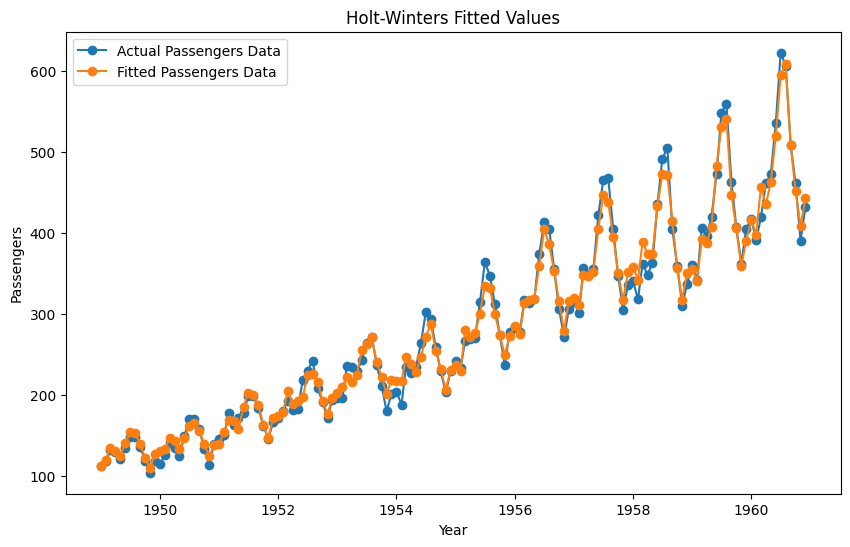

In [405]:
plt.figure(figsize=(10,6))

#### plot the original data points
plt.plot(df.index, df['Passengers'], marker='o',label='Actual Passengers Data')

#### plot the fitted data points
plt.plot(df.index, df['HW_Fitted'], marker='o', label = 'Fitted Passengers Data')

#### give the title of the graph
plt.title('Holt-Winters Fitted Values')

#### give the x axis of the graph
plt.xlabel('Year')

#### give the y axis of the graph
plt.ylabel('Passengers')

plt.legend()

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The actual passengers data shows an upward trend every year because the number of passengers increase every year.

2.  The fitted values have direct access to the actual observations and they follow the actual observations.

3.  As there is an upward trend in the actual passengers data, so there is a similar upward trend in the Fitted passengers data.

4.  So from the above graph, it is concluded that the fitted Passengers Data can capture the

    (a.)    Trend

    (b.)    Seasonality 

    (c.)    Levels

    and it works much better than the Simple Exponential Smoothing.

#### Step 10: Forecast the future values

In [406]:
#### Forecast the next 24 months

forecast_values = model_fit.forecast(steps=24)

In [407]:
forecast_values

1961-01-01    451.577623
1961-02-01    427.258401
1961-03-01    464.700002
1961-04-01    500.104310
1961-05-01    508.661977
1961-06-01    567.715214
1961-07-01    647.898705
1961-08-01    632.462579
1961-09-01    534.376074
1961-10-01    484.932893
1961-11-01    418.461534
1961-12-01    471.061680
1962-01-01    482.716224
1962-02-01    458.397001
1962-03-01    495.838602
1962-04-01    531.242910
1962-05-01    539.800578
1962-06-01    598.853814
1962-07-01    679.037305
1962-08-01    663.601180
1962-09-01    565.514675
1962-10-01    516.071494
1962-11-01    449.600135
1962-12-01    502.200280
Freq: MS, dtype: float64

#### OBSERVATIONS:

1.  The forecast method has predicted the airline passengers for the next 24 months.

#### Step 11: Plot the Original vs Forecasted values

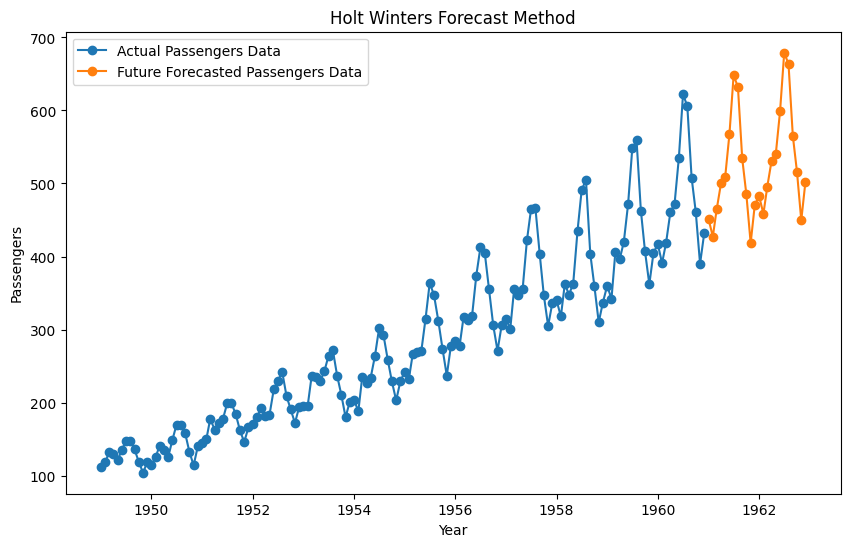

In [408]:
plt.figure(figsize=(10,6))

#### plot the original data points
plt.plot(df.index, df['Passengers'], marker = 'o', label='Actual Passengers Data')

#### plot the future forecasted data points
plt.plot(forecast_values.index, forecast_values.values,marker = 'o', label = 'Future Forecasted Passengers Data')

#### Give the title of the graph
plt.title('Holt Winters Forecast Method')

#### Give the x axis of the graph
plt.xlabel('Year')

#### give the y axis of the graph
plt.ylabel('Passengers')

#### give the legend of the graph
plt.legend()

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  Unlike the Simple Exponential Smoothing (SES) technique, where there was no trend, seasonality and level in the future forecasted data as all the future values had no access to the actual observations and they considered the same last actual value of the dataset, so the trend was constant and there was no seasonality in that.

2.  So the future forecasted values in SES was constant and there was no seasonality over that period of time.

3.  But in Holt Winters, The triple exponential smoothing technique has successfully captured trends, seasonality and levels in the data. So we can see from the above graph that the future forecasted values are showing

    (a.)    upward trends

    (b.)    repeating seasonal patterns

#### CONCLUSIONS:

1.  Unlike the SES where it has learned the level and has access to the current observations or the past values,The Exponential Smoothing (Holt-Winters) method has not only learned the level but also the trend and the seasonality.

2.  During the model training the Exponential Smoothing has learned the entire upward trend, so it follows the predicted values.

3.  During the future forecasting of the passengers data, the model has learnt the entire trend component, so the upward trend also follows the future values.

4.  So this is the reason that we can see in the graph that the upward trend also follows the future forecasted values.